In [6]:
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split

In [8]:
X = np.load("../data/landmarks/X_10000.npy")
y = np.load("../data/landmarks/y_10000.npy")

print(X.shape)
print(y.shape)
print("Classes:", len(np.unique(y)))

(10000, 64, 126)
(10000,)
Classes: 1998


In [9]:
unique_labels = np.unique(y)
label_to_index = {label: index for index, label in enumerate(unique_labels)}
y_indices = np.array([label_to_index[label] for label in y])

num_classes = len(unique_labels)

print(num_classes)
print(y.min(), y.max())

1998
0 1999


In [14]:
unique_labels = np.unique(y)

label_to_idx = {
    label: idx
    for idx, label in enumerate(unique_labels)
}

y = np.array(
    [
        label_to_idx[label]
        for label in y
    ],
    dtype=np.int32,
)

num_classes = len(unique_labels)

print(
    "Classes:",
    num_classes
)

print(
    "Range:",
    y.min(),
    y.max()
)

Classes: 1998
Range: 0 1997


In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.2,random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(8000, 64, 126)
(1000, 64, 126)
(1000, 64, 126)


In [16]:
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

In [17]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, d_model):
        super().__init__()
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length,
            output_dim=d_model
        )
        self.sequence_length = sequence_length

    def call(self, inputs):
        positions = tf.range(start=0,limit=self.sequence_length,delta=1)
        embedded_positions = self.position_embeddings(positions)
        return inputs + embedded_positions

In [18]:
class TransformerBlock(layers.Layer):
    def __init__(self,embed_dim,num_heads,ff_dim,rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim,activation="relu"),
            layers.Dense(embed_dim)
        ])

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs,inputs)

        attn_output = self.dropout1(attn_output,training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output,training=training)

        return self.layernorm2(out1 + ffn_output)

In [19]:
def build_model(num_classes):

    inputs = tf.keras.Input(shape=(64,126))

    x = layers.Dense(256)(inputs)
    x = PositionalEmbedding(64,256)(x)
    x = TransformerBlock(embed_dim=256,num_heads=8,ff_dim=512)(x)
    x = TransformerBlock(embed_dim=256,num_heads=8,ff_dim=512)(x)
    x = TransformerBlock(embed_dim=256,num_heads=8,ff_dim=512)(x)
    x = TransformerBlock(embed_dim=256,num_heads=8,ff_dim=512)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256,activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes,activation="softmax")(x)

    return Model(inputs,outputs)

In [20]:
model = build_model(num_classes)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 126)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64, 256)        │        32,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 64, 256)        │        16,384 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 64, 256)        │     2,367,488 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 64, 256)        │     2,367,488 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 64, 256)        │     2,367,488 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 64, 256)        │     2,367,488 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1998)           │       513,486 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,098,126 (38.52 MB)

 Trainable params: 10,098,126 (38.52 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5,restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2,factor=0.5)
]

In [23]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(
        X_val,
        y_val_cat
    ),
    epochs=50,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 2.5000e-04 - loss: 7.6163 - val_accuracy: 0.0000e+00 - val_loss: 7.5904 - learning_rate: 1.0000e-04
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 7.5000e-04 - loss: 7.4917 - val_accuracy: 0.0000e+00 - val_loss: 7.4136 - learning_rate: 1.0000e-04
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.0025 - loss: 7.2481 - val_accuracy: 0.0000e+00 - val_loss: 7.3218 - learning_rate: 1.0000e-04
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.0018 - loss: 7.1184 - val_accuracy: 0.0000e+00 - val_loss: 7.2848 - learning_rate: 1.0000e-04
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.0026 - loss: 7.0252 - val_accuracy: 0.0020 - val_loss: 7.2263 - learning_rate: 1.0000e-04
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.0052 - loss: 6.8863 - val_accuracy: 0.0030 - val_loss: 7.1568 - learning_rate: 1.0000e-04
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━

In [24]:
display(history.history["accuracy"][-1])
display(history.history["val_accuracy"][-1])
display(history.history["loss"][-1])
display(history.history["val_loss"][-1])


0.09324999898672104

0.017999999225139618

4.483182430267334

6.6395440101623535

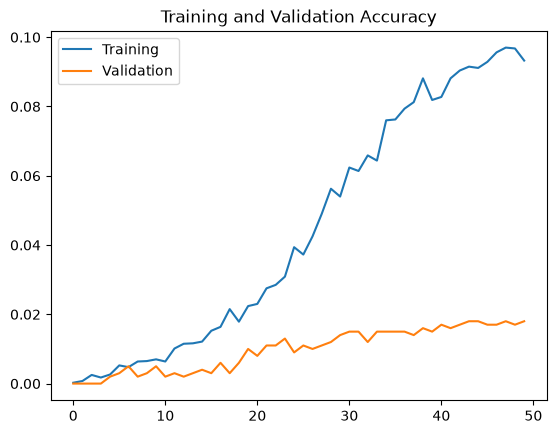

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"],label="train_accuracy")
plt.plot(history.history["val_accuracy"],label="val_accuracy")
plt.title("Training and Validation Accuracy")
plt.legend(["Training", "Validation"])
plt.show()

Conclusion:
Each class has just 4 samples hence the result is expected to be overfitted and innaccurate
In the next version, data augumentation will be used to increase the data samples.


In [ ]:
model.save("../data/asl_transformer_mark2.keras")

In [27]:
pred = model.predict(X_test[:1])
pred_class = np.argmax(pred)
true_class = y_test[:1]

print(pred_class, true_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
1307 [151]
